# Predicting Smartphone Addiction
**Kaggle Playground Series S6E8**: predict the probability that a person is addicted to their smartphone (`addicted_label`).

- **Metric:** ROC-AUC. Only the ranking of the predicted probabilities matters.
- **Data:** 691k training and 296k test rows with 9 numeric usage features (screen time and its breakdown, sleep,
  notifications, app opens) and 3 categoricals. **Every column has 4-20% missing values**, and train and test have
  different missing rates. Generated synthetically from a smartphone-addiction dataset whose page was removed during
  the competition.
- **Approach**, taken from the winning write-ups and the strongest public notebooks:
  1. the screen-time budget: daily screen time is always at least social + gaming + work/study, so a missing value
     can be bounded from the others (the 2nd-place team's breakthrough feature);
  2. features for the rule the source data was generated with (addicted when daily screen time > 8 h or social media
     > 4 h, not addicted when daily <= 6 h and social <= 4 h, a coin flip in between);
  3. value-frequency and fold-safe target encoding of the exact numeric values (the generator reuses a finite set of values);
  4. LightGBM and XGBoost on the same 5 folds and a logistic-regression stack on their out-of-fold logits.

The competition closed on 31 August 2026. The submission at the end is a late submission, which Kaggle still
scores on both the public and private leaderboards.

In [1]:
import io, subprocess, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb
import xgboost as xgb
from scipy.special import logit
from scipy.stats import rankdata
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import TargetEncoder

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 60)

COMP = 'playground-series-s6e8'
SEED = 42
N_FOLDS = 5
TARGET = 'addicted_label'

# Plot styling: fixed categorical slots, recessive grid
BLUE, ORANGE, AQUA = '#2a78d6', '#eb6834', '#1baf7a'
plt.rcParams.update({
    'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.color': '#e6e5e1', 'grid.linewidth': 0.6, 'axes.axisbelow': True,
    'axes.edgecolor': '#9a9994', 'axes.titleweight': 'bold', 'axes.titlesize': 11, 'font.size': 9,
    'lines.linewidth': 2,
})

## 1. Load data

In [2]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')
sample = pd.read_csv('sample_submission.csv')
print('train', train.shape, '| test', test.shape)
train.head()

train (691369, 14) | test (296302, 13)


,id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact,addicted_label
0,0,24.0,NaN,1.83,1.59,2.11,7.46,122.0,38.0,8.63,Male,Medium,No,1
1,1,19.0,5.97,1.08,NaN,3.03,8.22,76.0,19.0,NaN,Female,Medium,No,0
2,2,18.0,5.09,NaN,NaN,NaN,6.25,134.0,60.0,7.47,Female,Low,Yes,0
3,3,21.0,6.42,1.26,1.42,3.36,8.85,112.0,94.0,8.66,Other,Low,NaN,1
4,4,26.0,11.20,1.87,2.81,1.95,5.25,NaN,NaN,13.39,Female,Medium,No,1


## 2. EDA
### 2.1 Structure, missing values and target balance

In [3]:
NUMS = ['age', 'daily_screen_time_hours', 'social_media_hours', 'gaming_hours', 'work_study_hours', 'sleep_hours',
        'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time']
CATS = ['gender', 'stress_level', 'academic_work_impact']
FEATURES = NUMS + CATS

summary = pd.DataFrame({
    'dtype': train[FEATURES].dtypes.astype(str),
    'n_unique': train[FEATURES].nunique(),
    'train_missing_%': (train[FEATURES].isna().mean() * 100).round(2),
    'test_missing_%': (test[FEATURES].isna().mean() * 100).round(2),
})
display(summary)
print(f'Addicted: {train[TARGET].mean():.2%}')
print(f'Rows with at least one missing value: train {train[FEATURES].isna().any(axis=1).mean():.1%}, '
      f'test {test[FEATURES].isna().any(axis=1).mean():.1%}')

# The screen-time budget: daily >= social + gaming + work/study wherever all four are known
parts = ['social_media_hours', 'gaming_hours', 'work_study_hours']
both = pd.concat([train, test])
known = both[['daily_screen_time_hours'] + parts].notna().all(axis=1)
slack = both.loc[known, 'daily_screen_time_hours'] - both.loc[known, parts].sum(axis=1)
print(f'daily >= social + gaming + work on {(slack >= -1e-9).mean():.2%} of the {known.sum():,} complete rows')

,dtype,n_unique,train_missing_%,test_missing_%
age,float64,18,4.18,5.78
daily_screen_time_hours,float64,1389,13.86,11.07
social_media_hours,float64,721,19.38,16.00
gaming_hours,float64,401,18.34,20.05
work_study_hours,float64,600,7.45,9.37
sleep_hours,float64,451,6.43,7.58
notifications_per_day,float64,231,9.78,11.55
app_opens_per_day,float64,166,11.67,8.68
weekend_screen_time,float64,1437,16.21,17.11
gender,str,3,4.20,4.80


Addicted: 70.94%
Rows with at least one missing value: train 61.1%, test 61.8%
daily >= social + gaming + work on 100.00% of the 603,714 complete rows


### 2.2 The two columns that decide the label

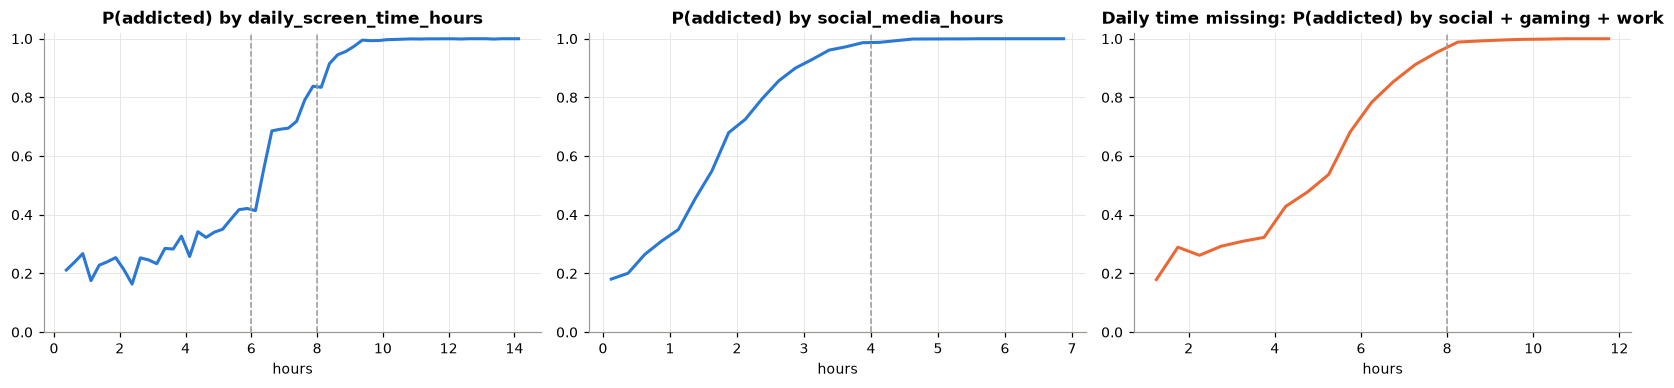

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3.6))
for ax, col, cut in zip(axes[:2], ['daily_screen_time_hours', 'social_media_hours'], [(6, 8), (4,)]):
    bins = pd.cut(train[col], np.arange(0, train[col].max() + 0.25, 0.25))
    g = train.groupby(bins, observed=True)[TARGET].agg(['mean', 'size'])
    g = g[g['size'] >= 100]
    ax.plot([iv.mid for iv in g.index], g['mean'], color=BLUE)
    for c in cut:
        ax.axvline(c, color='#9a9994', ls='--', lw=1)
    ax.set_title(f'P(addicted) by {col}'); ax.set_xlabel('hours'); ax.set_ylim(0, 1.02)

# Missing daily screen time: does the known part of the budget still tell us the answer?
miss = train[train['daily_screen_time_hours'].isna() & train[parts].notna().all(axis=1)]
b = pd.cut(miss[parts].sum(axis=1), np.arange(0, 12.5, 0.5))
g = miss.groupby(b, observed=True)[TARGET].agg(['mean', 'size'])
g = g[g['size'] >= 50]
axes[2].plot([iv.mid for iv in g.index], g['mean'], color=ORANGE)
axes[2].axvline(8, color='#9a9994', ls='--', lw=1)
axes[2].set_title('Daily time missing: P(addicted) by social + gaming + work'); axes[2].set_xlabel('hours'); axes[2].set_ylim(0, 1.02)
plt.tight_layout(); plt.show()

### 2.3 Train vs test (adversarial validation)

In [5]:
ADV_PARAMS = dict(objective='binary', learning_rate=0.1, num_leaves=63, verbose=-1, n_jobs=-1, seed=SEED)

def adversarial_auc(a, b, cols, n=150_000):
    a = a.sample(min(n, len(a)), random_state=SEED)
    b = b.sample(min(n, len(b)), random_state=SEED)
    Xab = pd.concat([a[cols], b[cols]], ignore_index=True)
    for c in Xab.select_dtypes(exclude='number').columns:
        Xab[c] = Xab[c].astype('category')
    t = np.r_[np.zeros(len(a)), np.ones(len(b))]
    Xa, Xb, ta, tb = train_test_split(Xab, t, test_size=0.3, random_state=SEED, stratify=t)
    m = lgb.train(ADV_PARAMS, lgb.Dataset(Xa, ta), 200)
    return roc_auc_score(tb, m.predict(Xb))

def missing_pattern(d):
    return d[FEATURES].isna().astype('int8')

print(f'Adversarial AUC train vs test, raw columns: {adversarial_auc(train, test, FEATURES):.4f}')
print(f'Adversarial AUC train vs test, missing-value pattern only: '
      f'{adversarial_auc(missing_pattern(train), missing_pattern(test), FEATURES):.4f}')

Adversarial AUC train vs test, raw columns: 0.5552


Adversarial AUC train vs test, missing-value pattern only: 0.5640


**EDA takeaways**
- The label follows the source rule closely: the addiction rate jumps above 8 h of daily screen time and above 4 h
  of social media, with a mixed band between 6 and 8 h.
- The budget identity holds on every complete row, so when daily screen time is missing, social + gaming + work is a
  hard lower bound for it. The right panel shows that bound still carries the 8-hour step.
- Train and test differ only in *how often* each column is missing, not in the values themselves. Trees handle NaN
  natively, and the bound features make missing rows less ambiguous.

## 3. Feature engineering
- **Budget features** (2nd place, public LightGBM notebooks): sum of the known parts, the unexplained remainder
  `daily - parts`, part shares, weekend vs weekday, and bounds: a lower bound for missing daily time and an upper
  bound for a missing part (`daily - other parts`).
- **Rule features:** "surely addicted" (daily lower bound > 8 or social > 4), "surely not addicted" (daily <= 6 and
  social upper bound <= 4), and the rule's verdict where it is decidable.
- **Ratios:** notifications and app opens per screen hour, screen time per sleep hour.
- **Missingness:** count of missing columns.
- **Exact values:** each numeric value's frequency in train + test and its fold-safe target encoding (in the CV loop),
  plus its decimal part, which the generator's rounding leaves as a fingerprint.

In [6]:
def make_features(df):
    out = df[FEATURES].copy()
    daily, social = df['daily_screen_time_hours'], df['social_media_hours']
    gaming, work = df['gaming_hours'], df['work_study_hours']
    known_parts = df[parts].sum(axis=1)                      # NaN treated as 0
    n_parts_missing = df[parts].isna().sum(axis=1)
    out['parts_sum'] = known_parts
    out['parts_missing'] = n_parts_missing
    out['daily_lb'] = daily.fillna(known_parts)              # daily >= parts, exact when daily is known
    out['remainder'] = daily - known_parts                   # unexplained screen time (an upper bound for any missing part)
    out['remainder_share'] = out['remainder'] / daily.clip(lower=0.1)
    out['parts_share'] = known_parts / out['daily_lb'].clip(lower=0.1)
    for p, name in zip(parts, ['social', 'gaming', 'work']):
        out[f'{name}_share'] = df[p] / out['daily_lb'].clip(lower=0.1)
    others_social = gaming.fillna(0) + work.fillna(0)
    out['social_ub'] = social.fillna(daily - others_social)  # missing social <= daily - gaming - work
    out['weekend_minus_daily'] = df['weekend_screen_time'] - daily
    out['weekend_minus_parts'] = df['weekend_screen_time'] - known_parts
    out['weekend_ratio'] = df['weekend_screen_time'] / daily.clip(lower=0.1)

    # Source rule: addicted if daily > 8 or social > 4; not addicted if daily <= 6 and social <= 4
    sure_yes = (out['daily_lb'] > 8) | (social > 4)
    sure_no = (daily <= 6) & (out['social_ub'] <= 4)
    out['rule_sure_yes'] = sure_yes.astype('int8')
    out['rule_sure_no'] = sure_no.astype('int8')
    out['rule_verdict'] = np.select([sure_yes, sure_no, daily.between(6, 8) & (out['social_ub'] <= 4)],
                                    [1.0, 0.0, 0.5], default=np.nan)
    out['daily_minus_8'] = out['daily_lb'] - 8
    out['social_minus_4'] = social - 4

    out['notif_per_hour'] = df['notifications_per_day'] / out['daily_lb'].clip(lower=0.1)
    out['opens_per_hour'] = df['app_opens_per_day'] / out['daily_lb'].clip(lower=0.1)
    out['notif_per_open'] = df['notifications_per_day'] / df['app_opens_per_day'].clip(lower=1)
    out['screen_per_sleep'] = out['daily_lb'] / df['sleep_hours'].clip(lower=0.1)
    out['n_missing'] = df[FEATURES].isna().sum(axis=1)
    for c in NUMS:
        out[f'dec_{c}'] = (df[c] % 1).round(2)
    return out

full = pd.concat([make_features(train), make_features(test)], ignore_index=True)
for c in NUMS:
    full[f'cnt_{c}'] = full[c].map(full[c].value_counts()).astype('float32')
for c in CATS:
    full[c] = full[c].astype('category')

n_tr = len(train)
X = full.iloc[:n_tr].reset_index(drop=True)
X_test = full.iloc[n_tr:].reset_index(drop=True)
y = train[TARGET].astype(int).values
del full
print('features:', X.shape[1], '| train', X.shape, '| test', X_test.shape)

features: 53 | train (691369, 53) | test (296302, 53)


## 4. Cross-validated models
Stratified 5-fold CV. The exact-value target encoding of the numeric columns is fitted inside each fold on its
training rows (cross-fitted internally by scikit-learn's `TargetEncoder`, so no row sees its own label).

In [7]:
FOLDS = list(StratifiedKFold(N_FOLDS, shuffle=True, random_state=SEED).split(X, y))
TE_COLS = NUMS
TE_NAMES = [f'te_{c}' for c in TE_COLS]

def add_target_encoding(Xtr, ytr, others):
    te = TargetEncoder(target_type='binary', smooth='auto', cv=5, shuffle=True, random_state=SEED)
    def attach(d, enc):
        return pd.concat([d.reset_index(drop=True), pd.DataFrame(enc, columns=TE_NAMES)], axis=1)
    Xtr = attach(Xtr, te.fit_transform(Xtr[TE_COLS].astype(str), ytr))
    return Xtr, [attach(d, te.transform(d[TE_COLS].astype(str))) for d in others]

def run_cv(name, fit_predict, use_te=True):
    oof, pred, t0 = np.zeros(len(X)), np.zeros(len(X_test)), time.time()
    for k, (tr_idx, va_idx) in enumerate(FOLDS):
        Xtr, Xva, Xte = X.iloc[tr_idx], X.iloc[va_idx], X_test
        if use_te:
            Xtr, (Xva, Xte) = add_target_encoding(Xtr, y[tr_idx], [Xva, Xte])
        oof[va_idx], p = fit_predict(Xtr, y[tr_idx], Xva, y[va_idx], Xte)
        pred += p / N_FOLDS
        print(f'  fold {k}: {roc_auc_score(y[va_idx], oof[va_idx]):.5f}')
    score = roc_auc_score(y, oof)
    print(f'{name}: OOF AUC {score:.5f}  ({time.time() - t0:.0f}s)')
    return dict(oof=oof, pred=pred, score=score)

results, importances = {}, []

In [8]:
# Settings from the strongest public single LightGBM (wide trees, aggressive column sampling, fine bins);
# learning rate 0.06 instead of its 0.01 to fit a laptop CPU
LGB_PARAMS = dict(objective='binary', metric='auc', learning_rate=0.06, num_leaves=127, min_child_samples=200,
                  feature_fraction=0.35, bagging_fraction=0.75, bagging_freq=5, lambda_l1=0.1, lambda_l2=1.0,
                  max_bin=1023, verbose=-1, n_jobs=-1, seed=SEED)

def lgb_fit_predict(Xtr, ytr, Xva, yva, Xte):
    m = lgb.train(LGB_PARAMS, lgb.Dataset(Xtr, ytr), 20000, valid_sets=[lgb.Dataset(Xva, yva)],
                  callbacks=[lgb.early_stopping(150, verbose=False)])
    importances.append(pd.Series(m.feature_importance('gain'), Xtr.columns))
    it = m.best_iteration
    return m.predict(Xva, num_iteration=it), m.predict(Xte, num_iteration=it)

results['lgb'] = run_cv('LightGBM', lgb_fit_predict)

  fold 0: 0.96749


  fold 1: 0.96834


  fold 2: 0.96837


  fold 3: 0.96881


  fold 4: 0.96793


LightGBM: OOF AUC 0.96819  (256s)


In [9]:
XGB_PARAMS = dict(objective='binary:logistic', eval_metric='auc', tree_method='hist', learning_rate=0.08,
                  max_depth=7, min_child_weight=10, subsample=0.8, colsample_bytree=0.5, reg_lambda=3.0,
                  max_bin=512, max_cat_to_onehot=1, n_jobs=-1, seed=SEED)

def xgb_fit_predict(Xtr, ytr, Xva, yva, Xte):
    dtr = xgb.DMatrix(Xtr, ytr, enable_categorical=True)
    dva = xgb.DMatrix(Xva, yva, enable_categorical=True)
    m = xgb.train(XGB_PARAMS, dtr, 20000, evals=[(dva, 'va')], early_stopping_rounds=150, verbose_eval=False)
    rng = (0, m.best_iteration + 1)
    return m.predict(dva, iteration_range=rng), m.predict(xgb.DMatrix(Xte, enable_categorical=True), iteration_range=rng)

results['xgb'] = run_cv('XGBoost', xgb_fit_predict)

  fold 0: 0.96764


  fold 1: 0.96854


  fold 2: 0.96836


  fold 3: 0.96888


  fold 4: 0.96790
XGBoost: OOF AUC 0.96826  (1083s)


## 5. Stack
A logistic regression on the models' out-of-fold logits, cross-validated on the same folds so its OOF AUC is honest.
A plain rank average is shown for comparison.

In [10]:
names = list(results)
display(pd.Series({n: results[n]['score'] for n in names}, name='OOF AUC').sort_values(ascending=False).round(5).to_frame())
display(pd.DataFrame({n: results[n]['oof'] for n in names}).corr(method='spearman').round(4))

def to_logit(p):
    return logit(np.clip(p, 1e-6, 1 - 1e-6))

Z = np.column_stack([to_logit(results[n]['oof']) for n in names])
Z_test = np.column_stack([to_logit(results[n]['pred']) for n in names])

stack_oof = np.zeros(len(y))
for tr_idx, va_idx in FOLDS:
    lr = LogisticRegression(C=1.0, max_iter=1000).fit(Z[tr_idx], y[tr_idx])
    stack_oof[va_idx] = lr.predict_proba(Z[va_idx])[:, 1]
stacker = LogisticRegression(C=1.0, max_iter=1000).fit(Z, y)
stack_test = stacker.predict_proba(Z_test)[:, 1]

rank_oof = np.mean([rankdata(results[n]['oof']) / len(y) for n in names], axis=0)
rank_test = np.mean([rankdata(results[n]['pred']) / len(X_test) for n in names], axis=0)

blend_scores = pd.Series({
    'logistic stack': roc_auc_score(y, stack_oof),
    'rank average': roc_auc_score(y, rank_oof),
    'best single model': max(results[n]['score'] for n in names),
}).round(5)
print(blend_scores.to_string())
print('Stack coefficients:', dict(zip(names, stacker.coef_[0].round(3).tolist())))

use_stack = blend_scores['logistic stack'] >= blend_scores['rank average']
final_name = 'logistic stack' if use_stack else 'rank average'
final_oof_auc = blend_scores[final_name]
final_test = stack_test if use_stack else rank_test
print(f'Submitting the {final_name}: OOF AUC {final_oof_auc:.5f}')

,OOF AUC
xgb,0.96826
lgb,0.96819


,lgb,xgb
lgb,1.0000,0.9953
xgb,0.9953,1.0000


logistic stack       0.96855
rank average         0.96855
best single model    0.96826
Stack coefficients: {'lgb': 0.467, 'xgb': 0.527}
Submitting the logistic stack: OOF AUC 0.96855


### Feature importance (LightGBM, gain, averaged over folds)

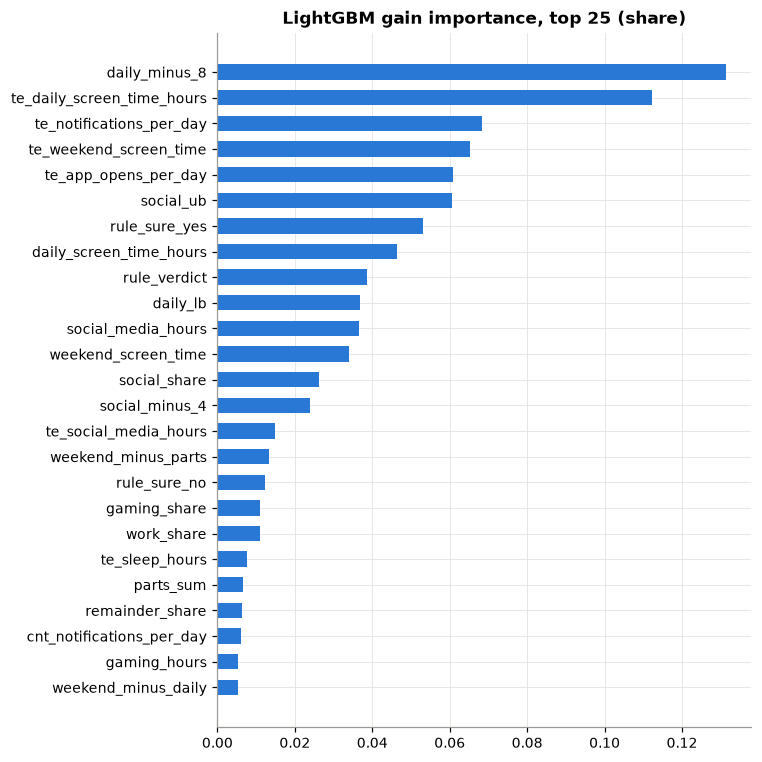

In [11]:
imp = pd.concat(importances, axis=1).mean(axis=1)
imp = (imp / imp.sum()).sort_values().tail(25)
fig, ax = plt.subplots(figsize=(7, 7))
ax.barh(imp.index, imp.values, color=BLUE, height=0.6)
ax.set_title('LightGBM gain importance, top 25 (share)')
plt.tight_layout(); plt.show()

## 6. Submission

In [12]:
sub = sample[['id']].copy()
assert (sub['id'].values == test['id'].values).all()
sub[TARGET] = final_test
sub.to_csv('submission.csv', index=False)
print(sub.shape); display(sub.head())

(296302, 2)


,id,addicted_label
0,691369,0.999603
1,691370,0.955186
2,691371,0.846971
3,691372,0.996304
4,691373,0.998624


In [13]:
def kaggle_cli(*args):
    # The CLI prints a UTF-8 progress bar; Windows' default cp1252 decoding crashes on it
    return subprocess.run(['kaggle', 'competitions', *args], capture_output=True, text=True,
                          encoding='utf-8', errors='replace')

SUBMIT = True   # set to False to re-run the notebook without submitting again
msg = f'{" + ".join(names)} | {final_name} | OOF AUC {final_oof_auc:.5f}'
if SUBMIT:
    out = kaggle_cli('submit', COMP, '-f', 'submission.csv', '-m', msg)
    print(out.stdout[-2000:], out.stderr[-300:])

99 submissions remaining today.
Successfully submitted to Predicting Smartphone Addiction 880k/7.69M [00:01<00:04, 1.54MB/s]
 21%|██        | 1.61M/7.69M [00:01<00:02, 3.04MB/s]
 26%|██▌       | 2.02M/7.69M [00:01<00:01, 3.25MB/s]
 48%|████▊     | 3.66M/7.69M [00:01<00:00, 6.66MB/s]
 87%|████████▋ | 6.72M/7.69M [00:01<00:00, 13.1MB/s]
100%|██████████| 7.69M/7.69M [00:03<00:00, 2.59MB/s]



In [14]:
# Wait for scoring. The competition is closed, so the late submission shows both public and private scores.
for _ in range(30):
    subs = pd.read_csv(io.StringIO(kaggle_cli('submissions', '-c', COMP, '-v').stdout))
    if 'pending' not in str(subs.loc[0, 'status']).lower():
        break
    time.sleep(20)
display(subs.head(3))

,ref,fileName,date,description,status,publicScore,privateScore
0,56967078,submission.csv,2026-10-08 18:41:35.653000,lgb + xgb | logistic stack | OOF AUC 0.96855,SubmissionStatus.COMPLETE,0.96985,0.96964
